# **Section 1 — Project Introduction**

> This project analyzes 9 years of Nifty 50 data (2016-2025) to identify market regimes — Bull, Bear and Sideways — and evaluate which technical indicators best characterize each regime. ANOVA testing is used to statistically validate indicator behavior across regimes.

In [56]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from scipy.stats import f_oneway
from sklearn.preprocessing import StandardScaler

# **Section 2 — Data Loading and Health Check**

In [57]:
df1 = pd.read_csv('final_data_fixed.csv').copy()

In [58]:
df = df1.copy()

In [59]:
df.shape

(2332, 94)

In [60]:
df['date'].duplicated().sum()

np.int64(0)

In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df.isnull().sum().sum()

np.int64(905)

In [63]:
df = df.dropna()

In [64]:
df.isnull().sum().sum()

np.int64(0)

In [65]:
df.shape

(2133, 94)

In [66]:
df = df[['high', 'low', 'open', 'volume', 'close', 'date','return_1d',
       'return_2d', 'return_5d', 'return_10d', 'cum_return_5d',
    'rsi', 'macd', 'bb_width', 'volume_ratio', 'adx']]

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2133 entries, 199 to 2331
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   high           2133 non-null   float64
 1   low            2133 non-null   float64
 2   open           2133 non-null   float64
 3   volume         2133 non-null   int64  
 4   close          2133 non-null   float64
 5   date           2133 non-null   object 
 6   return_1d      2133 non-null   float64
 7   return_2d      2133 non-null   float64
 8   return_5d      2133 non-null   float64
 9   return_10d     2133 non-null   float64
 10  cum_return_5d  2133 non-null   float64
 11  rsi            2133 non-null   float64
 12  macd           2133 non-null   float64
 13  bb_width       2133 non-null   float64
 14  volume_ratio   2133 non-null   float64
 15  adx            2133 non-null   float64
dtypes: float64(14), int64(1), object(1)
memory usage: 283.3+ KB


# **Section 3 — Univariate Analysis**

In [68]:
# RSI

In [69]:
df['rsi'].mean(), df['rsi'].median() ,df['rsi'].std(), df['rsi'].skew()

(np.float64(55.23910022221404),
 55.92964510536561,
 12.720120343790361,
 np.float64(-0.26358547410566935))

<Axes: xlabel='rsi', ylabel='Count'>

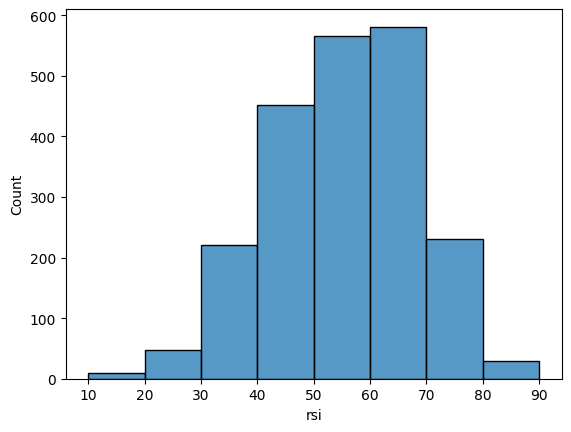

In [70]:
sns.histplot(df['rsi'],bins=[10,20,30,40,50,60,70,80,90])

<Axes: >

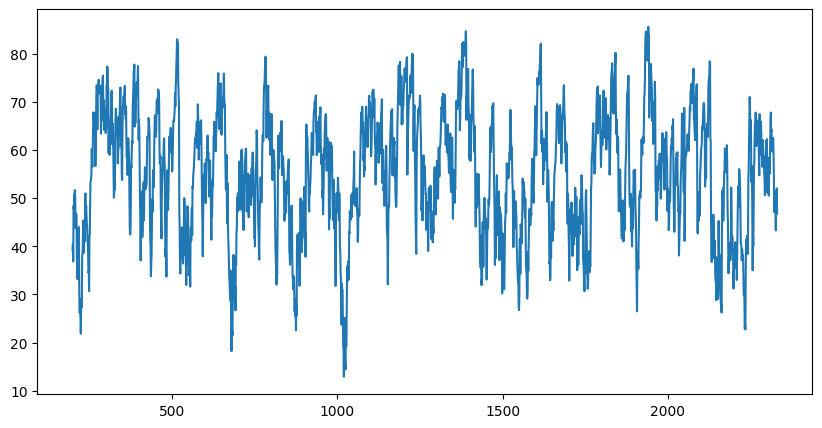

In [71]:
df['rsi'].plot(kind='line',figsize=(10,5))

 **RSI interpretation**

 RSI values distribution follows a normal distribution. It means most of the time the market is steady.

 If we see a histogram the range from 50-70 has the highest count, which means the market has more buying bids by which rsi tend to lie more time in these range.

In [72]:
# MACD

In [73]:
df['macd'].mean(), df['macd'].median() ,df['macd'].std(), df['macd'].skew()

(np.float64(53.873228452598674),
 65.65569493155817,
 171.2038754936665,
 np.float64(-1.128256075257954))

In [74]:
fig = go.Figure(
    data=[go.Bar(y=df['macd'])],
    layout_title_text="A Figure Displayed MACD"
)
fig.show()

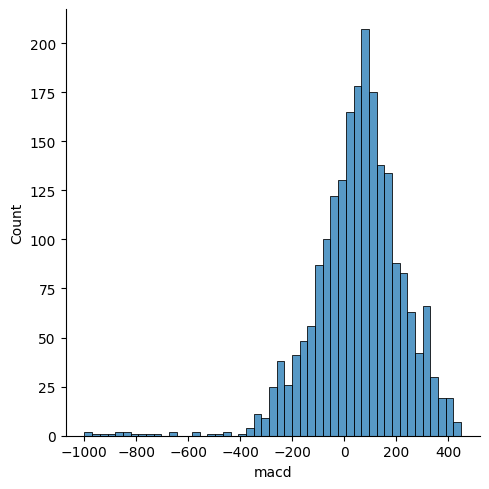

In [75]:
sns.displot(df['macd'])

- Interpretation

    mean and the median are positive , these tell us that the market is accelerating at good speed.

    One thing to be noticed , macd dropped till -1000, which makes the difference between mean and median.

    Mostly macd lies between -200 to 200. which means as macd reaches 200 we can plan to cut-off our holdings and if it crosses 400 then definitely either come out from market or be with very less stock and vice versa.


In [76]:
## BB_Width

In [77]:
df['bb_width'].mean(), df['bb_width'].median() ,df['bb_width'].std(), df['bb_width'].skew()

(np.float64(6.54736833645778),
 5.503867432878754,
 4.7556504301004345,
 np.float64(5.493211688279415))

In [78]:
fig = go.Figure(
    data=[go.Bar(y=df['bb_width'])],
    layout_title_text="A Figure Displayed with fig.show()"
)
fig.show()

In [79]:
fig = px.histogram(df, x="bb_width")
fig.show()


- Interpretation

    mean and median suggest that the market is mostly low or moderate volatility.

    Means if the value goes below the mean or median meaning the market is getting squeezed and there could be a possible move at any side and if it is above the mean median there is more volatility and now this could be steady or can continue the movement.

    What exactly we can say is markets always try to be between a specific range which is 3-7 if markets cross these would try to come in these range.

    If bb_width below 3 is ready for move and if bb_width is above 7 either the movement will continue or getting started squeezing means adjusting your trading decision.


In [80]:
# ADX

In [81]:
df['adx'].mean(), df['adx'].median() ,df['adx'].std(), df['adx'].skew()

(np.float64(33.42140401265071),
 31.29455212866593,
 12.073116526108828,
 np.float64(0.8114742947278722))

In [82]:
fig = go.Figure(
    data=[go.Bar(y=df['adx'])],
    layout_title_text="A Figure Displayed with fig.show()"
)
fig.show()

In [83]:
fig = px.histogram(df, x="adx")
fig.show()

<Axes: xlabel='adx', ylabel='close'>

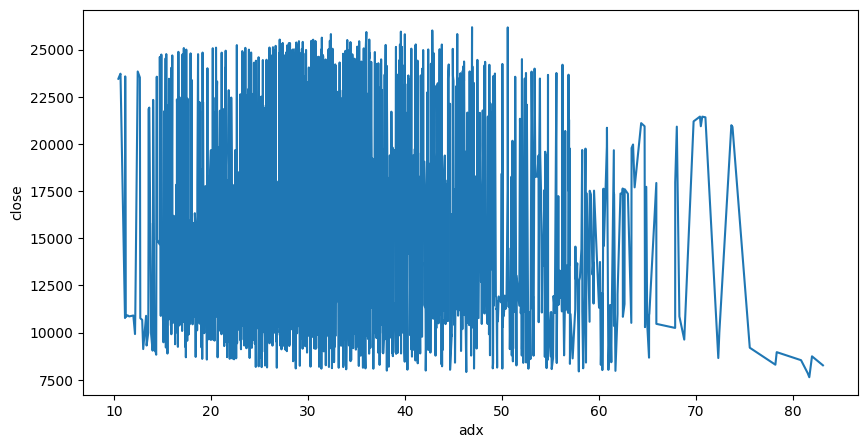

In [84]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df,x='adx',y='close')

- Interpretation

    ADX is skewed towards right side. Which means many times adx revolve around 20-40

  

In [85]:
# Volume ratio

In [86]:
df['volume_ratio'].mean(), df['volume_ratio'].median() ,df['volume_ratio'].std(), df['volume_ratio'].skew()

(np.float64(1.0061483369848503),
 0.959676120810618,
 0.26699737250077527,
 np.float64(1.719184945711686))

In [87]:
fig = go.Figure(
    data=[go.Bar(y=df['volume_ratio'])],
    layout_title_text="Volume ratio line chart."
)
fig.show()

In [88]:
fig = px.histogram(df, x="volume_ratio")
fig.show()

- Interpretation

    The mean of volume ratio is 1, which means most of days volume is same as
    20 days average volume.

    One thing volume from -0.5 to 1.5 follows normal distribution. But actually
    slightly right skewed but we can say it is normally distributed.


# **Section 4 — Bivariate Analysis**

In [89]:
return_features = ['return_1d',
       'return_2d', 'return_5d', 'return_10d', 'cum_return_5d']

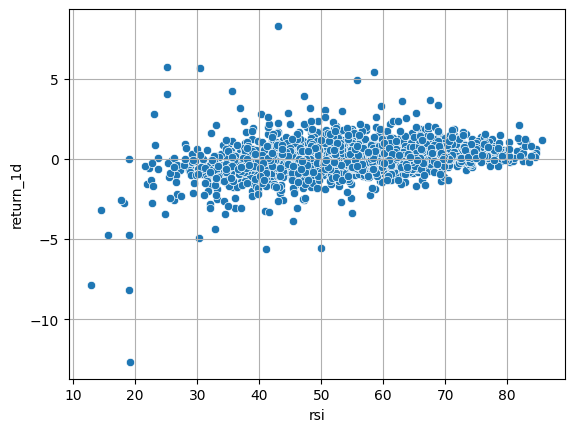

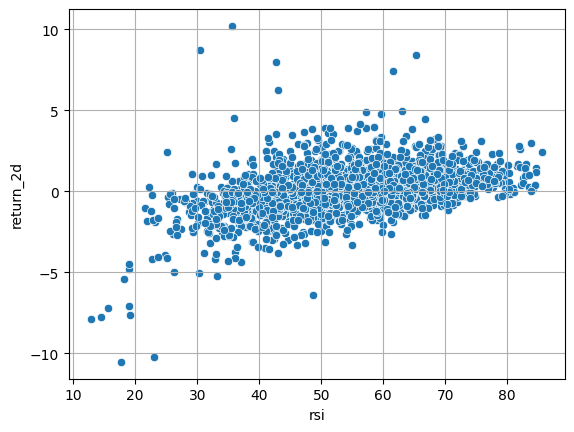

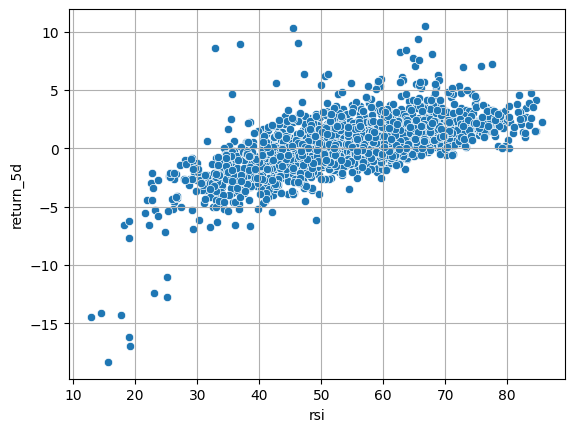

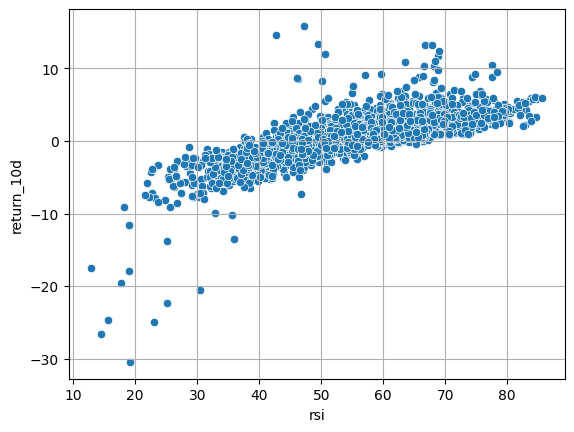

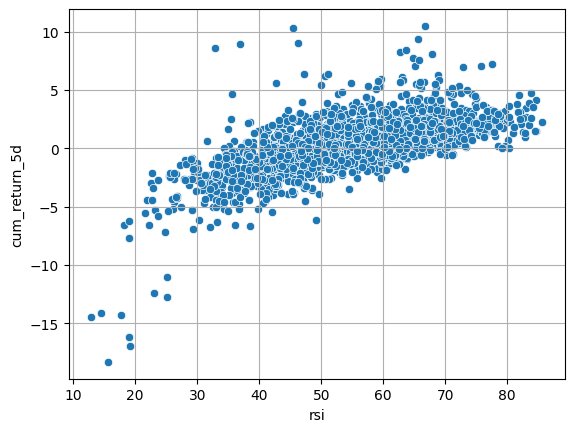

In [90]:
for i in return_features:
  sns.scatterplot(data=df,x='rsi',y=i)
  plt.grid(True)
  # plt.scatter(df['rsi'],df[i])
  plt.show()

In [91]:
for i in return_features:
  print(f"Correlation of RSI with {i} is {df['rsi'].corr(df[i])}")

Correlation of RSI with return_1d is 0.3150582628075579
Correlation of RSI with return_2d is 0.4447479607861493
Correlation of RSI with return_5d is 0.6400630222976966
Correlation of RSI with return_10d is 0.7463469576068124
Correlation of RSI with cum_return_5d is 0.6400630222976966


1 day and 2 day Returns are not predictable using RSI alone but RSI has positive correlation with 5d and 10 d returns.

it means if rsi increases 10 days , 5 days return and 5 day cummulative return increases.
Below rsi 30 the return is unexpected but as the rsi increase above 30 the returns also increases with a respective correlation mentioned above.

on left side of all chart below rsi 30 as day inncreases looses also increases. which states that if RSI fall below 30 don't hold it , cut down your position.

So what trader can do?
If RSI falls below cut down your position. And IF RSI Increases you can hold a position for 1-2 week.

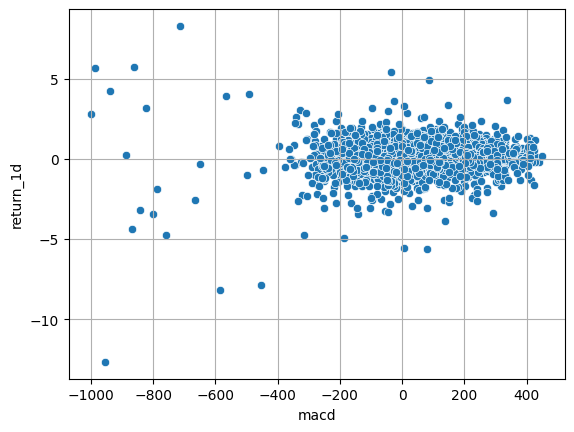

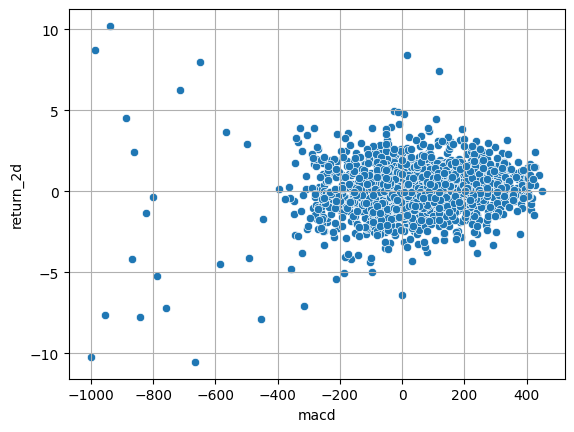

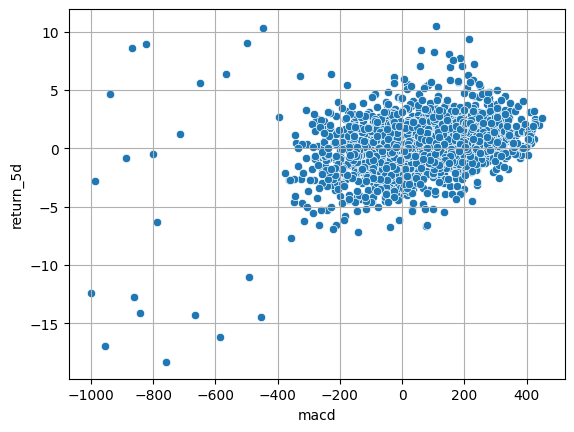

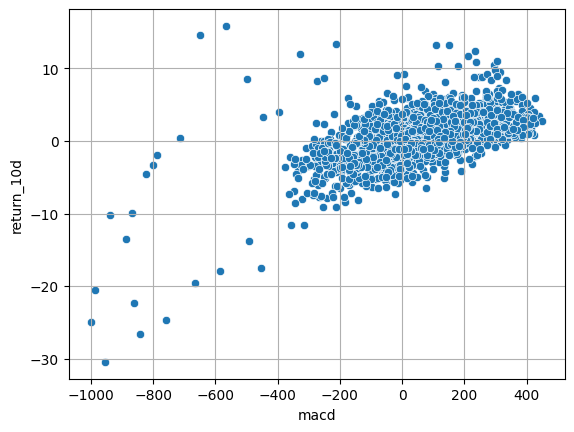

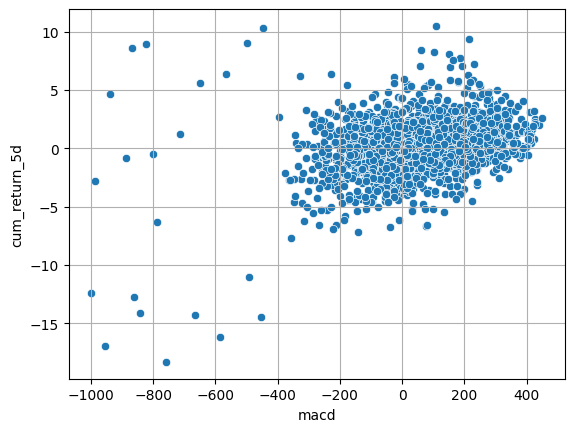

In [92]:
for i in return_features:
  sns.scatterplot(data=df,x='macd',y=i)
  plt.grid(True)
  plt.show()

In [93]:
for i in return_features:
  print(f"Correlation of MACD with {i} is {df['macd'].corr(df[i])}")

Correlation of MACD with return_1d is 0.06816423337033271
Correlation of MACD with return_2d is 0.13596320903056916
Correlation of MACD with return_5d is 0.3348618952348463
Correlation of MACD with return_10d is 0.5937172198788362
Correlation of MACD with cum_return_5d is 0.3348618952348463


MACD behaves similarly to RSI.

When MACD is deeply negative — below -200 — losses compound over 10 days.

The worst MACD value of -1000 occurred on March 24 2020 — the COVID crash bottom.

This confirms MACD as a strong bearish regime signal.

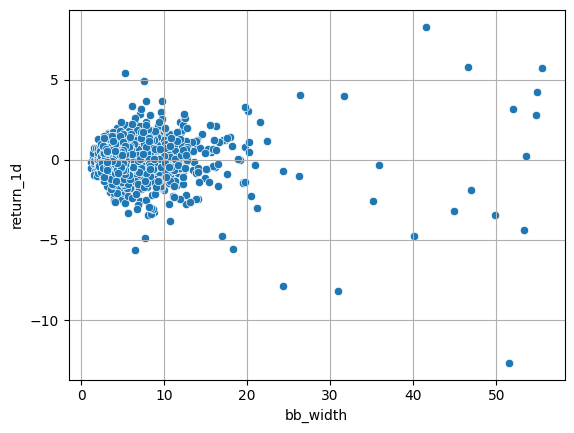

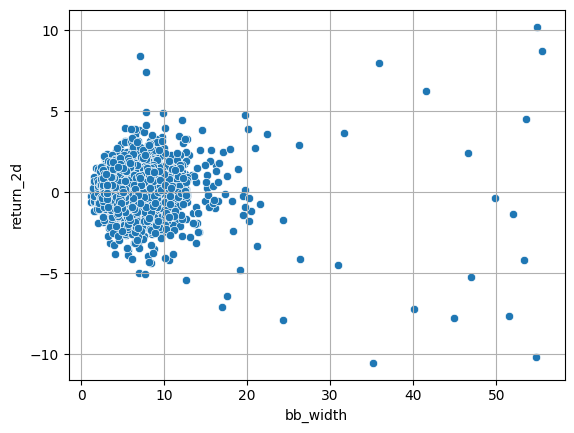

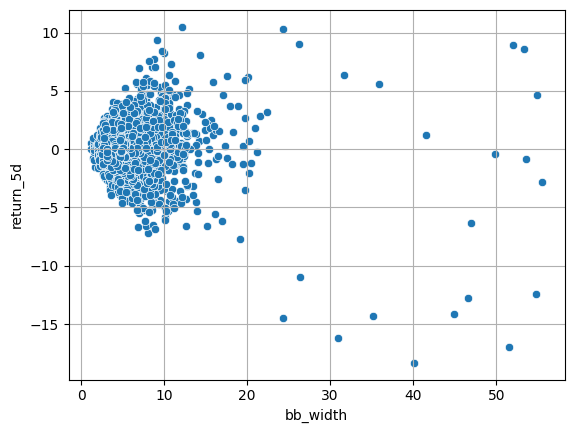

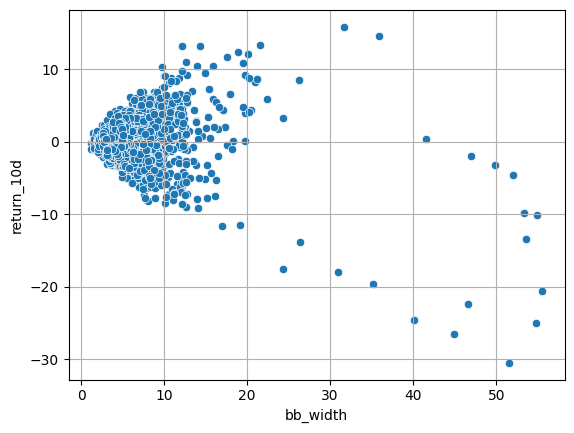

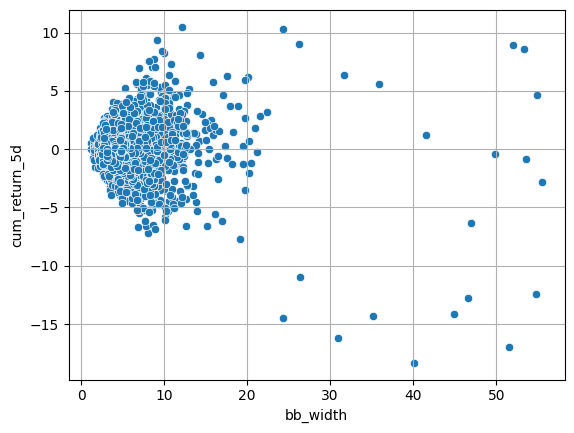

In [94]:
for i in return_features:
  sns.scatterplot(data=df,x='bb_width',y=i)
  plt.grid(True)
  plt.show()

In [95]:
for i in return_features:
  print(f"Correlation of BB Width with {i} is {df['bb_width'].corr(df[i])}")

Correlation of BB Width with return_1d is -0.013124527429852866
Correlation of BB Width with return_2d is -0.03207999474055995
Correlation of BB Width with return_5d is -0.0871329156125058
Correlation of BB Width with return_10d is -0.17405133197173406
Correlation of BB Width with cum_return_5d is -0.0871329156125058


High BB Width does not predict direction of returns.

But it predicts magnitude — when BB Width is above 15, returns swing wildly in both directions.

This confirms BB Width as a volatility regime signal, not a direction signal.

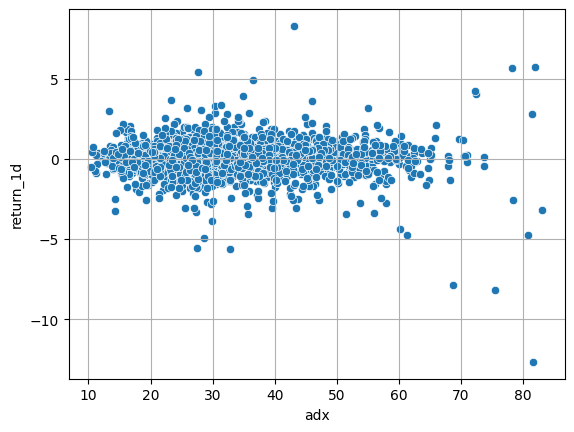

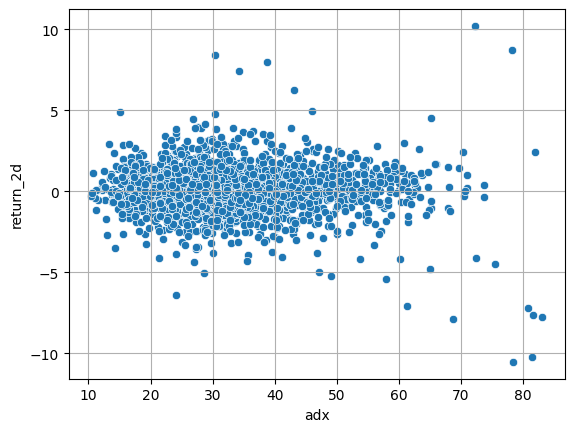

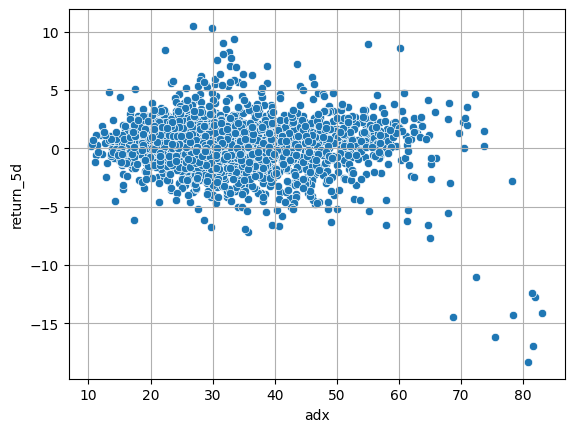

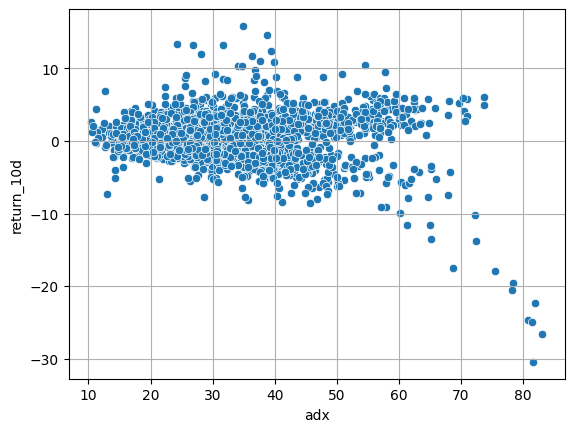

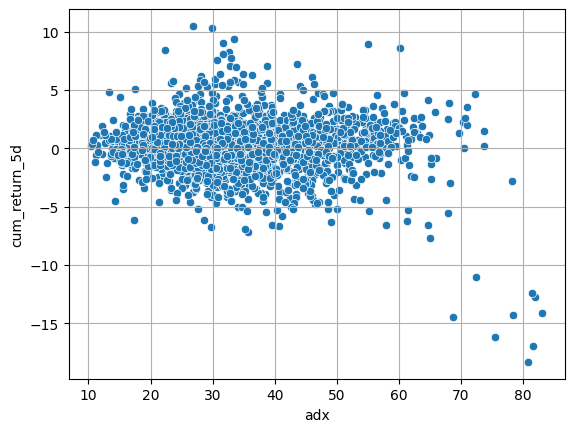

In [96]:
for i in return_features:
  sns.scatterplot(data=df,x='adx',y=i)
  plt.grid(True)
  plt.show()

In [97]:
for i in return_features:
  print(f"Correlation of ADX with {i} is {df['adx'].corr(df[i])}")

Correlation of ADX with return_1d is -0.040613388469143856
Correlation of ADX with return_2d is -0.06553937345870883
Correlation of ADX with return_5d is -0.10574708125765239
Correlation of ADX with return_10d is -0.10871371576412474
Correlation of ADX with cum_return_5d is -0.10574708125765239


ADX shows no strong relationship with short term returns.

But high ADX above 40 combined with good returns confirms a strong trending regime.

Low ADX below 20 means returns are random and unpredictable — sideways regime

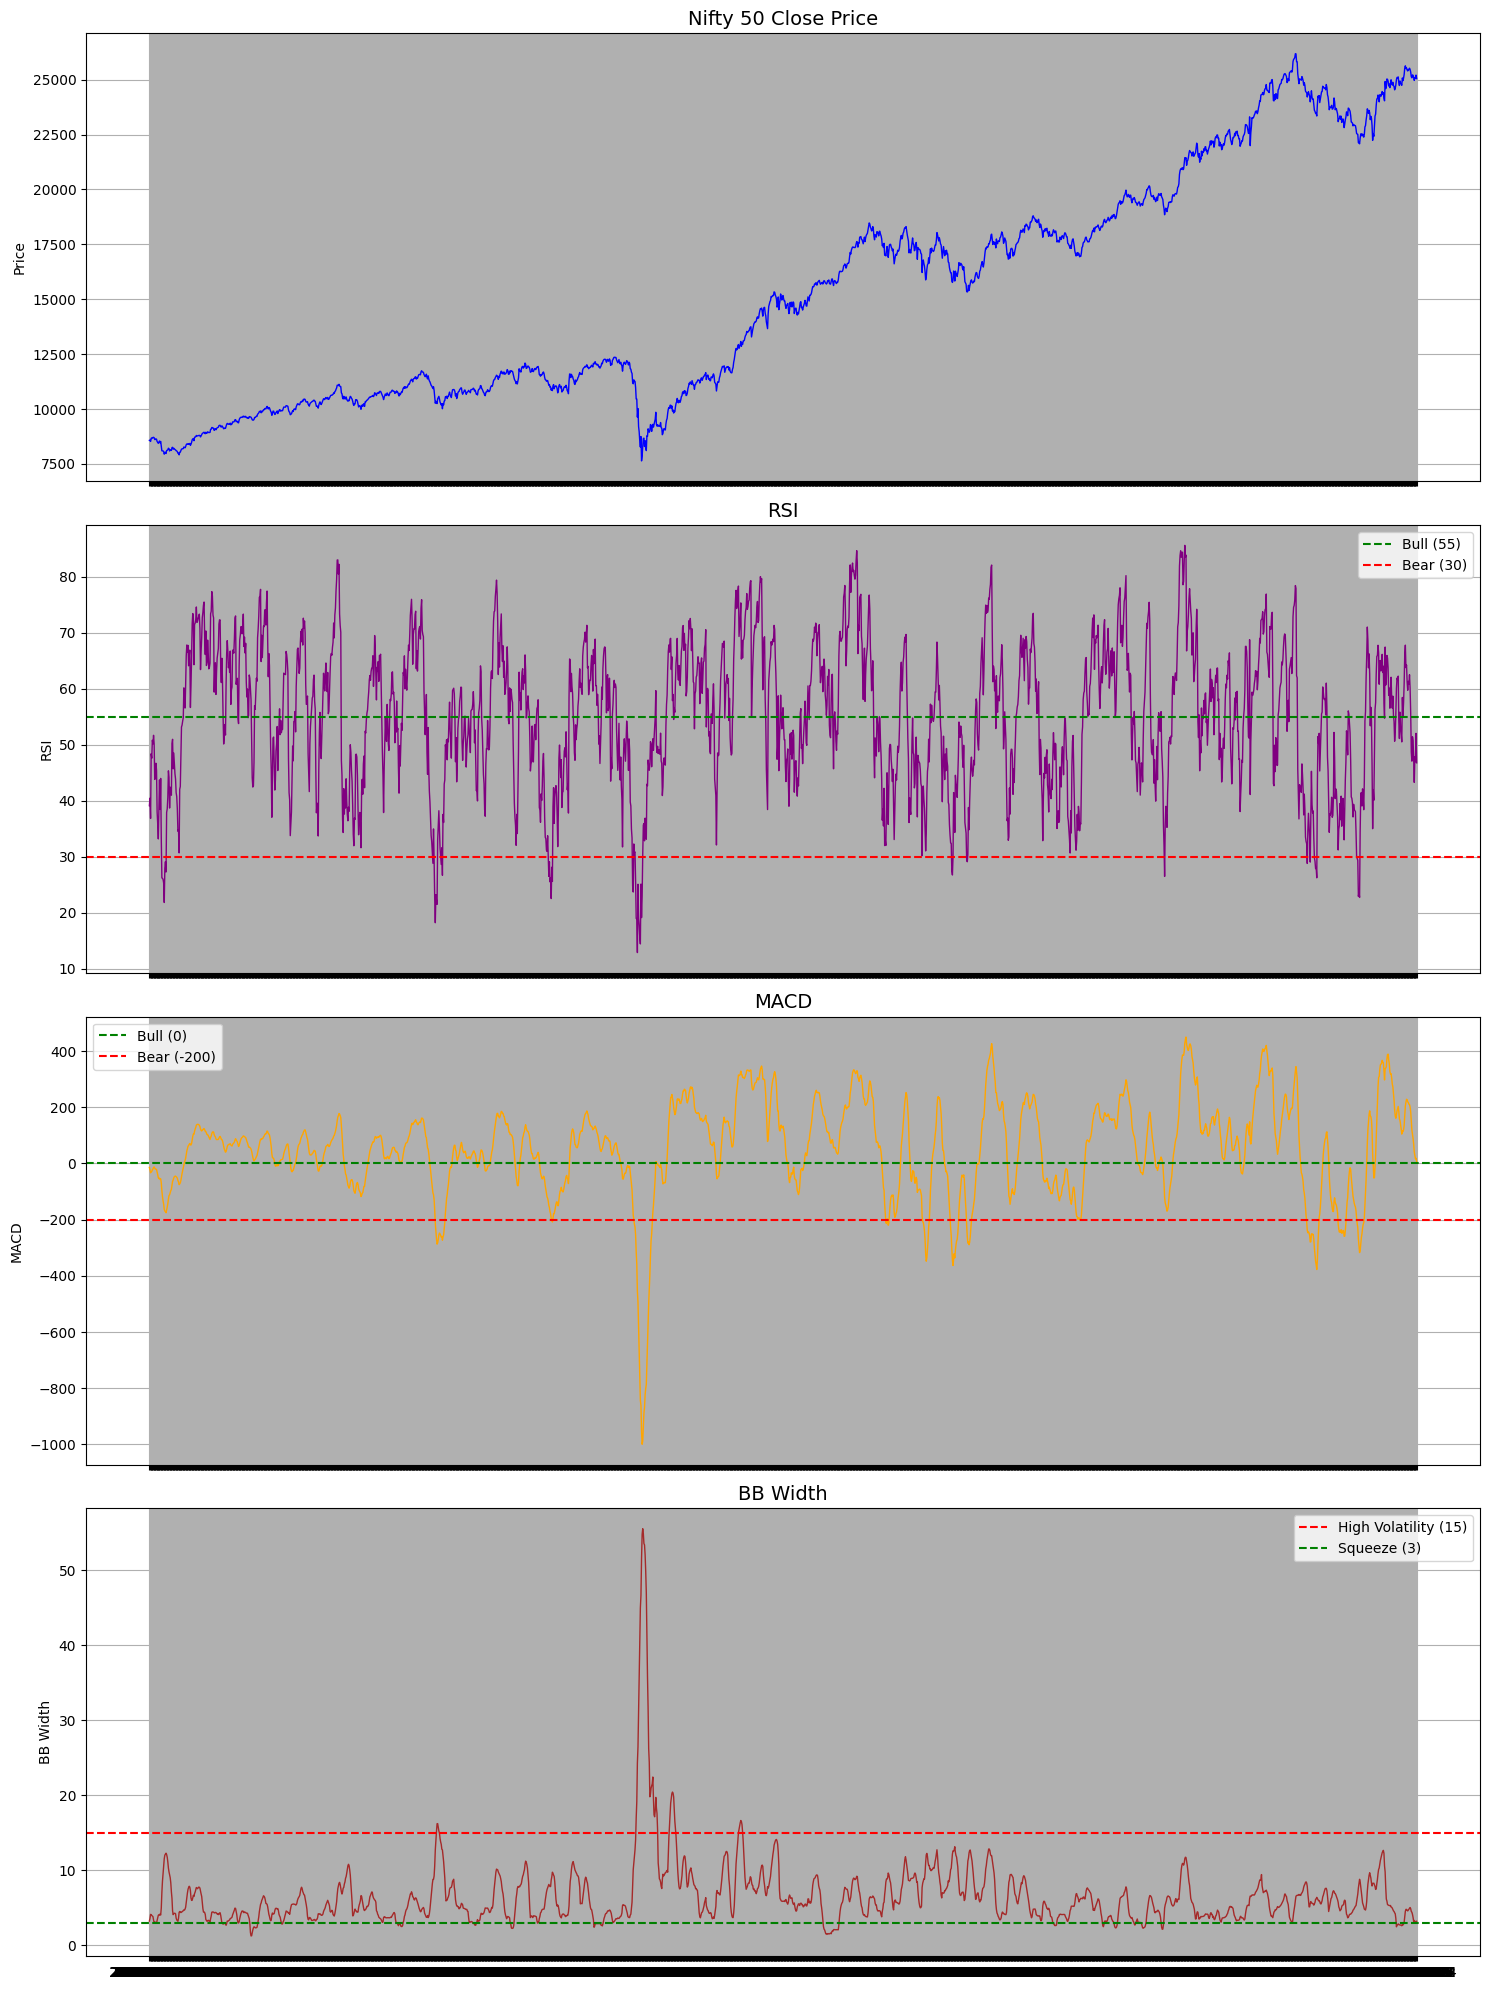

In [98]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(4, 1, figsize=(15, 20), sharex=True)

axes[0].plot(df['date'], df['close'], color='blue', linewidth=1)
axes[0].set_title('Nifty 50 Close Price', fontsize=14)
axes[0].set_ylabel('Price')
axes[0].grid(True)

axes[1].plot(df['date'], df['rsi'], color='purple', linewidth=1)
axes[1].axhline(y=55, color='green', linestyle='--', label='Bull (55)')
axes[1].axhline(y=30, color='red', linestyle='--', label='Bear (30)')
axes[1].set_title('RSI', fontsize=14)
axes[1].set_ylabel('RSI')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(df['date'], df['macd'], color='orange', linewidth=1)
axes[2].axhline(y=0, color='green', linestyle='--', label='Bull (0)')
axes[2].axhline(y=-200, color='red', linestyle='--', label='Bear (-200)')
axes[2].set_title('MACD', fontsize=14)
axes[2].set_ylabel('MACD')
axes[2].legend()
axes[2].grid(True)

axes[3].plot(df['date'], df['bb_width'], color='brown', linewidth=1)
axes[3].axhline(y=15, color='red', linestyle='--', label='High Volatility (15)')
axes[3].axhline(y=3, color='green', linestyle='--', label='Squeeze (3)')
axes[3].set_title('BB Width', fontsize=14)
axes[3].set_ylabel('BB Width')
axes[3].legend()
axes[3].grid(True)

plt.tight_layout()
plt.show()

## What This Chart is Telling You — Period by Period



> 🟡 Period 1 — Sideways (2016 to early 2017)
Look at the top panel. Price is flat between 7500 to 8500.
Now look at the other panels during the same time:



**RSI → oscillating between 40-60. Never strongly above 55 for long**

**MACD → hovering near 0. No strong direction**

**BB Width → very low, mostly below 3**



**Market had no conviction. Indicators confirm — no trend, low volatility, RSI neutral. Classic sideways regime.**



> 🟢 Period 2 — Bull (2017 to early 2020)
Price steadily rising from 8500 to 12500.

**RSI → mostly staying above 55 green line**

**MACD → mostly positive, above 0**

**BB Width → calm between 3-7**


**"All three indicators quietly confirm sustained buying. This is the textbook bull regime."**
> 🔴 Period 3 — Bear Crisis (Feb to April 2020)
This is the most important part of your chart.
Look at all 4 panels at exactly 2020:

**Price → vertical drop from 12500 to 7500**

**RSI → crashes below 30 — touches 10**

**MACD → spikes to -1000 — the extreme outlier you found**

**BB Width → explodes to 55 — the only time it ever crossed the red line**


**"Every single indicator screamed crisis simultaneously. This is March 2020 — COVID crash. RSI, MACD and BB Width all hit their worst values at exactly the same time confirming this as an extreme bearish regime."**


> 🟢 Period 4 — Strong Bull (April 2020 to Oct 2021)
Price rockets from 7500 to 18000. The fastest bull run in your dataset.

**RSI → strongly above 55**

**MACD → jumps to 200-400 range**

**BB Width → comes back down to normal after COVID spike**


> 🟡 Period 5 — Volatile Sideways (2022 to 2023)
Price moves between 16000-18000 with choppy movement.

**RSI → oscillating frequently above and below 55**

**MACD → crossing zero multiple times — no sustained direction**

**BB Width → slightly elevated but not extreme**



> 🟢 Period 6 — Bull (2024 to 2025)
Price pushes to new highs above 22000.

**RSI → above 55 for extended periods**

**MACD → positive**

**BB Width → calm**


### The Single Most Important Finding From This Chart

**"The three indicators — RSI, MACD and BB Width — did NOT predict the regime in advance. But they confirmed it in real time. When all three crossed their thresholds together — that confirmation was reliable. No single indicator alone was sufficient."**

# **Section 5 — Regime Detection**

In [99]:
def label_regime(date):
    if date >= '2016-01-01' and date < '2017-01-01':
        return 'Sideways'
    elif date >= '2017-01-01' and date < '2020-02-01':
        return 'Bull'
    elif date >= '2020-02-01' and date < '2020-06-01':
        return 'Bear'
    elif date >= '2020-06-01' and date < '2021-10-01':
        return 'Bull'
    elif date >= '2021-10-01' and date < '2023-03-01':
        return 'Sideways'
    elif date >= '2023-03-01' and date < '2024-09-01':
        return 'Bull'
    elif date >= '2024-09-01' and date < '2025-04-01':
        return 'Sideways'
    else:
        return 'Bull'

df['regime'] = df['date'].apply(label_regime)

In [100]:
print(df['regime'].value_counts())
print()
print(df['regime'].value_counts(normalize=True) * 100)

regime
Bull        1509
Sideways     548
Bear          76
Name: count, dtype: int64

regime
Bull        70.745429
Sideways    25.691514
Bear         3.563057
Name: proportion, dtype: float64


<Axes: xlabel='date', ylabel='close'>

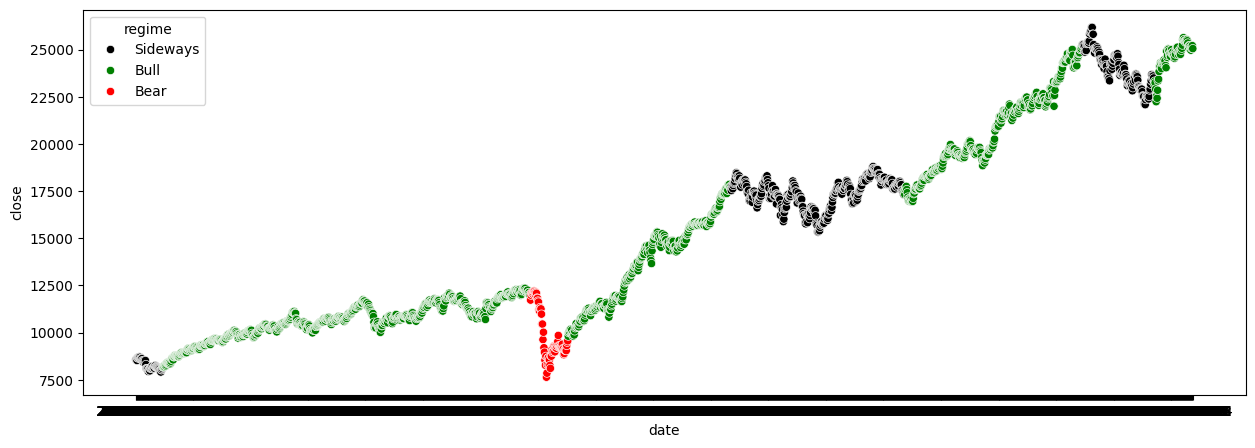

In [101]:
plt.figure(figsize=(15,5))
sns.scatterplot(data=df,x='date',y='close',hue='regime',palette={
    'Bull':'green','Bear':'red','Sideways':'black'
})

# **Section 6 — Indicator Behavior Per Regime**

In [102]:
indicators = ['rsi', 'macd', 'bb_width', 'adx', 'volume_ratio']

bull = df[df['regime'] == 'Bull']
bear = df[df['regime'] == 'Bear']
sideways = df[df['regime'] == 'Sideways']

print("="*60)
print("ANOVA Test — Do indicators differ across regimes?")
print("="*60)

for indicator in indicators:
    stat, p_value = f_oneway(
        bull[indicator],
        bear[indicator],
        sideways[indicator]
    )

    significance = "✅ Significant" if p_value < 0.05 else "❌ Not Significant"
    print(f"\n{indicator.upper()}")
    print(f"F-statistic : {stat:.2f}")
    print(f"P-value     : {p_value:.6f}")
    print(f"Result      : {significance}")

ANOVA Test — Do indicators differ across regimes?

RSI
F-statistic : 181.15
P-value     : 0.000000
Result      : ✅ Significant

MACD
F-statistic : 298.01
P-value     : 0.000000
Result      : ✅ Significant

BB_WIDTH
F-statistic : 412.17
P-value     : 0.000000
Result      : ✅ Significant

ADX
F-statistic : 1.68
P-value     : 0.186229
Result      : ❌ Not Significant

VOLUME_RATIO
F-statistic : 1.99
P-value     : 0.137189
Result      : ❌ Not Significant


In [103]:
print("\n" + "="*60)
print("Average indicator values per regime")
print("="*60)
print(df.groupby('regime')[indicators].mean().round(2))


Average indicator values per regime
            rsi    macd  bb_width    adx  volume_ratio
regime                                                
Bear      40.87 -271.63     19.48  35.76          1.06
Bull      58.22   96.53      5.85  33.23          1.01
Sideways  49.04  -18.44      6.68  33.61          1.00


/tmp/ipykernel_37515/640027904.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_37515/640027904.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_37515/640027904.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




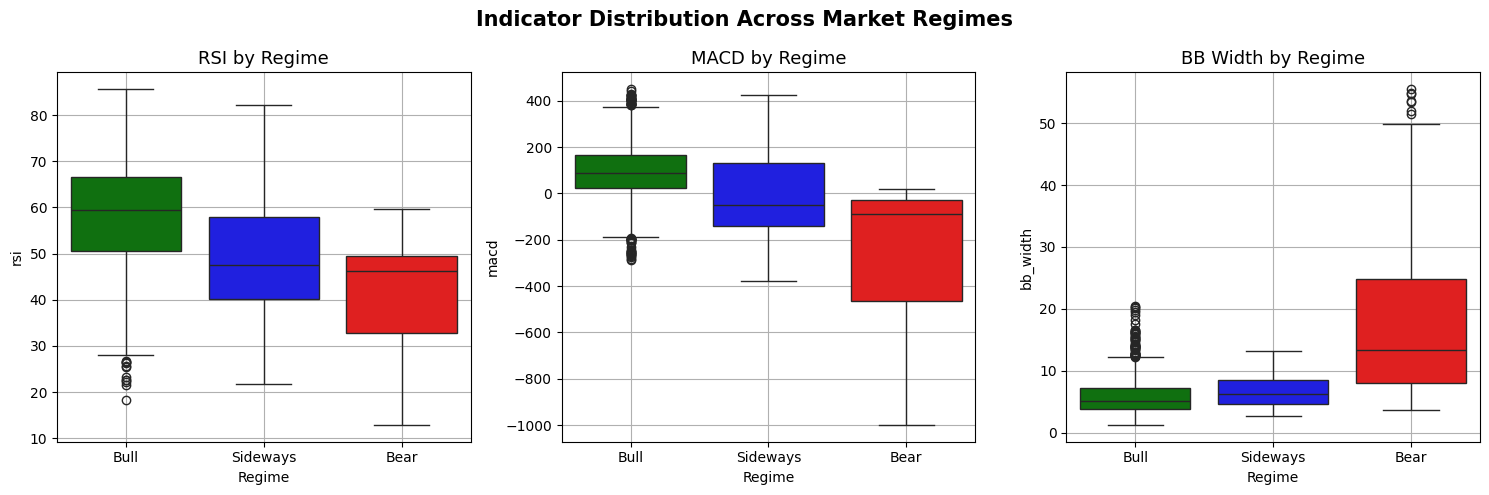

In [104]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

indicators = ['rsi', 'macd', 'bb_width']
titles = ['RSI by Regime', 'MACD by Regime', 'BB Width by Regime']
colors = {'Bull': 'green', 'Bear': 'red', 'Sideways': 'blue'}

for i, (indicator, title) in enumerate(zip(indicators, titles)):
    order = ['Bull', 'Sideways', 'Bear']
    sns.boxplot(
        data=df,
        x='regime',
        y=indicator,
        order=order,
        palette=colors,
        ax=axes[i]
    )
    axes[i].set_title(title, fontsize=13)
    axes[i].set_xlabel('Regime')
    axes[i].grid(True)

plt.suptitle(
    'Indicator Distribution Across Market Regimes',
    fontsize=15,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

# **Section 7 — Conclusions and Business Recommendations**

## Findings


### The Three Key Business Insights


> Insight 1 — BB Width is your strongest alarm bell

  **BB Width jumps from 5.85 in Bull to 19.48 in Bear — a 3x increase. When BB Width crosses above 15 — market is entering crisis territory. This is the earliest and strongest regime signal.**



> Insight 2 — MACD swing is dramatic

  **MACD swings from +96 in Bull to -271 in Bear — a total swing of 367 points. This confirms MACD as the strongest momentum regime indicator. When MACD crosses below -200 — bear regime is confirmed.**



> Insight 3 — ADX and Volume Ratio are regime-blind

  **Both failed ANOVA test. This is a critical finding — these indicators look active and meaningful but statistically they cannot differentiate market regimes. A trader relying on ADX or Volume Ratio alone to identify regime would be misled.**



### Business recommendations.



#### Traders to confirm regiem use this range for swing trading.



#### According to data , here are the range of values which confirm the regiem


  | Indicator | Bull | Bear | Sideways | Reliable? |
  |---|---|---|---|---|
  | RSI | 58 | 41 | 49 | ✅ Yes |
  | MACD | +97 | -272 | -18 | ✅ Yes |
  | BB Width | 5.8 | 19.5 | 6.7 | ✅ Yes |
  | ADX | 33 | 36 | 34 | ❌ No |
  | Volume Ratio | 1.01 | 1.06 | 1.00 | ❌ No |




### Conclusion

  **ANOVA testing across 2313 trading days confirmed that RSI, MACD and BB Width are statistically significant regime indicators with p-values of 0.000.**


  **BB Width showed the strongest differentiation with F-statistic of 412 — nearly doubling from 5.85 in Bull to 19.48 in Bear regime.**


  **MACD showed the largest absolute swing — from +96.53 in Bull to -271.63 in Bear.**


  **Contrary to common belief, ADX and Volume Ratio failed to show statistically significant differences across regimes — suggesting these indicators are better used for trade timing within a regime rather than regime identification itself.**
  

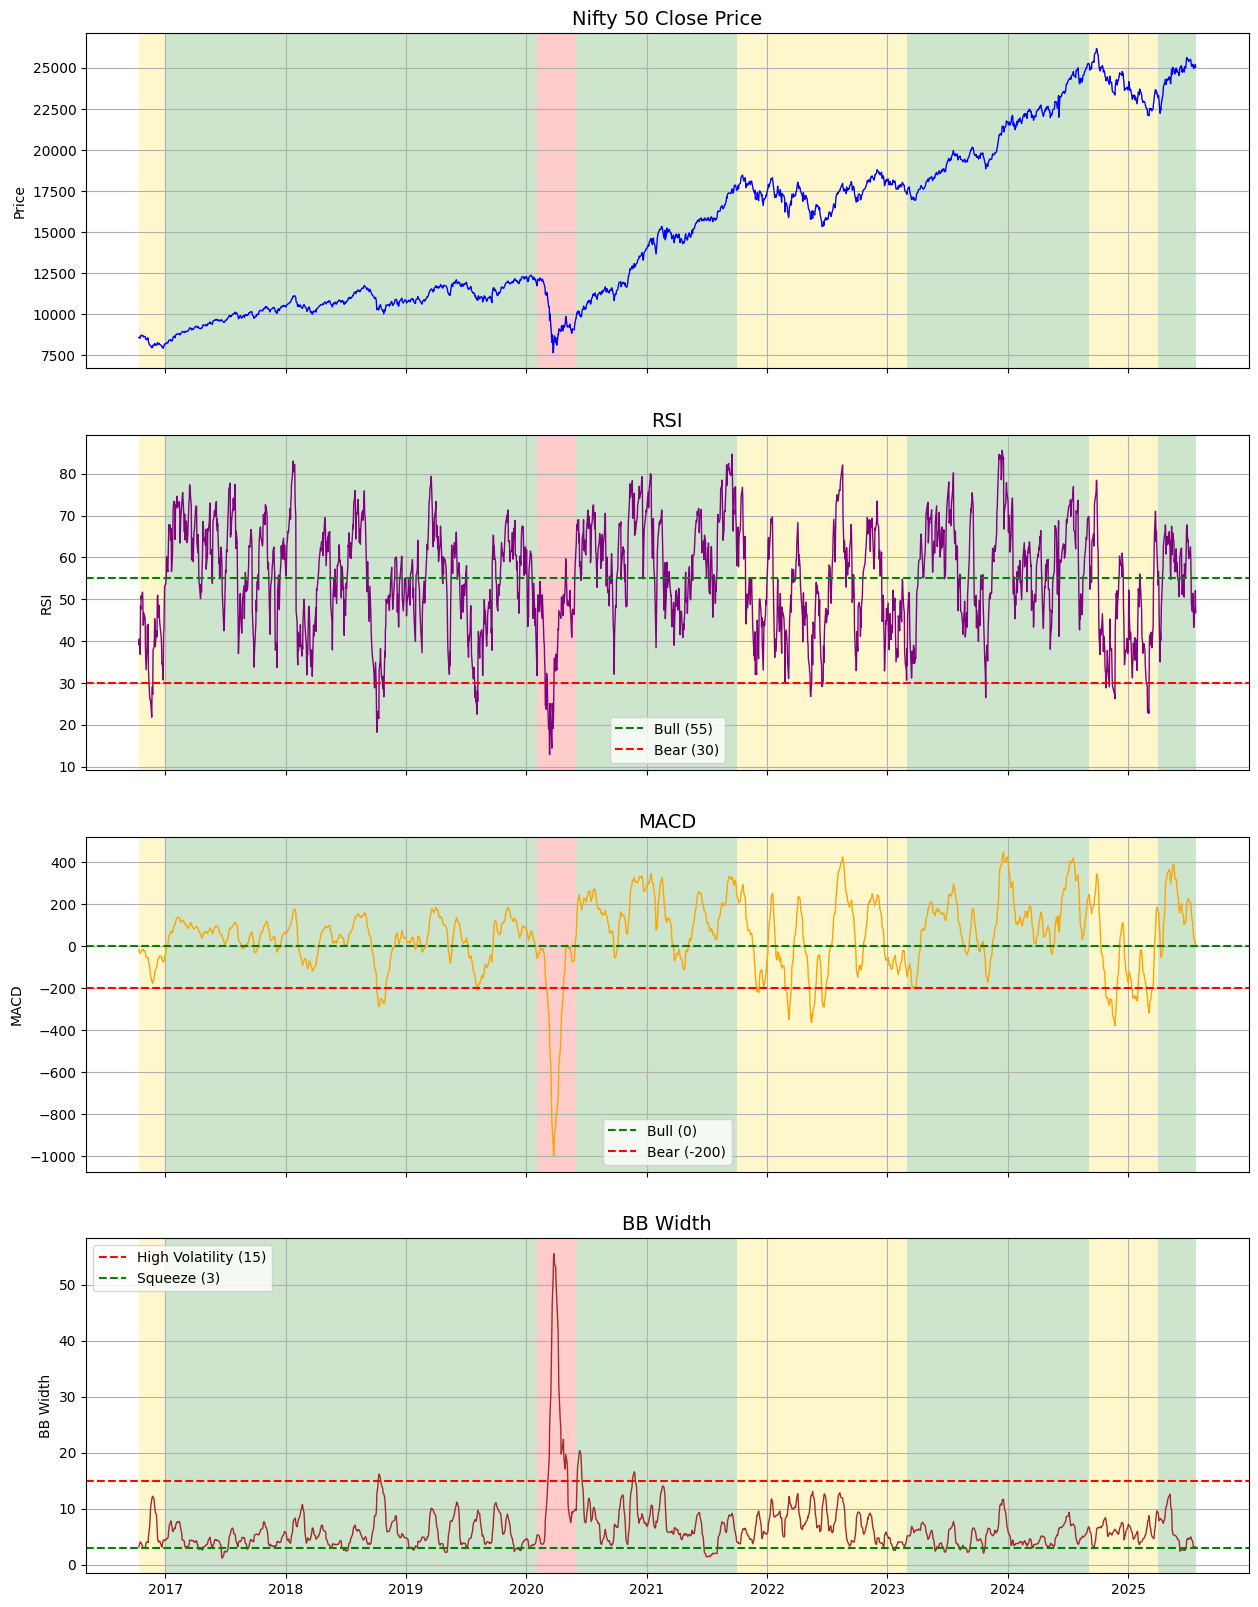

In [105]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


df['date'] = df['date'].sort_values()
df['date'] = pd.to_datetime(df['date'])

fig, axes = plt.subplots(4, 1, figsize=(15, 20), sharex=True)

axes[0].plot(df['date'], df['close'], color='blue', linewidth=1)
axes[0].set_title('Nifty 50 Close Price', fontsize=14)
axes[0].set_ylabel('Price')
axes[0].grid(True)

axes[1].plot(df['date'], df['rsi'], color='purple', linewidth=1)
axes[1].axhline(y=55, color='green', linestyle='--', label='Bull (55)')
axes[1].axhline(y=30, color='red', linestyle='--', label='Bear (30)')
axes[1].set_title('RSI', fontsize=14)
axes[1].set_ylabel('RSI')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(df['date'], df['macd'], color='orange', linewidth=1)
axes[2].axhline(y=0, color='green', linestyle='--', label='Bull (0)')
axes[2].axhline(y=-200, color='red', linestyle='--', label='Bear (-200)')
axes[2].set_title('MACD', fontsize=14)
axes[2].set_ylabel('MACD')
axes[2].legend()
axes[2].grid(True)

axes[3].plot(df['date'], df['bb_width'], color='brown', linewidth=1)
axes[3].axhline(y=15, color='red', linestyle='--', label='High Volatility (15)')
axes[3].axhline(y=3, color='green', linestyle='--', label='Squeeze (3)')
axes[3].set_title('BB Width', fontsize=14)
axes[3].set_ylabel('BB Width')
axes[3].legend()
axes[3].grid(True)

# Shade background by regime
regime_colors = {'Bull': 'green', 'Bear': 'red', 'Sideways': 'gold'}

current_regime = None
start_date = None

for _, row in df[['date', 'regime']].iterrows():
    if row['regime'] != current_regime:
        if current_regime is not None:
            for ax in axes:
                ax.axvspan(start_date, row['date'],
                           color=regime_colors[current_regime],
                           alpha=0.2, linewidth=0, zorder=0)
        current_regime = row['regime']
        start_date = row['date']

# Final block
if current_regime is not None:
    for ax in axes:
        ax.axvspan(start_date, df['date'].iloc[-1],
                   color=regime_colors[current_regime],
                   alpha=0.2, linewidth=0, zorder=0)

### Final Summary

> **In 9 years of Nifty 50 data, market regimes are most clearly characterised by three indicators: RSI (momentum), MACD (trend direction), and BB Width (volatility expansion). ADX and Volume Ratio are not reliable regime discriminators. Analysts and fund managers should build regime monitoring dashboards around the RSI + MACD + BB Width trio — treating any period where all three simultaneously signal stress as a high-conviction Bear regime alert.**

